## Example: Iterative Bayesian updating with a Gaussian mean model (RWMH posterior + PPC)

### Goal
We simulate 3 incoming batches of data. After each batch we:
1) produce an updated posterior object over the parameter vector $\mu \in \mathbb{R}^2$,  
2) generate a small posterior predictive forecast, and  
3) compute a posterior predictive check (PPC) p-value based on a chosen statistic.

This is meant to showcase the “distributions-in → distributions-out” workflow pattern.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from probpipe import (
    SimpleLikelihood,
    RWMH, 
    IterativeForecaster,
    PosteriorPredictiveChecker,
    Gaussian,
    EmpiricalDistribution
    )


### Probabilistic model

**Unknown parameter**  
We want to infer the 2D mean vector $\mu \in \mathbb{R}^2$ from observed data. 
This represents the location parameter of a Gaussian distribution.


**Prior**  
$\mu \sim \mathcal{N}(m_0, \Sigma_0)$, where 
$m_0 = \begin{bmatrix}0\\0\end{bmatrix}$, 
$\Sigma_0 = I_2.$

This represents our initial belief: we expect $\mu$ to be near zero with unit variance in each dimension.

`prior` encodes $p(\mu) = \mathcal{N}(m_0,\Sigma_0)$.


In [2]:
prior = Gaussian(mean=np.array([0.0, 0.0]), cov=np.eye(2))


**Likelihood wrapper**

`SimpleLikelihood` defines a likelihood family where:

$x \mid \mu \sim \mathcal{N}(\mu, I_2)$,
i.e. the unknown parameter is plugged into the distribution’s `mean` field, while `cov` is fixed.

For a batch $D=\{x_1,\dots,x_n\}$,
$\log p(D\mid\mu)=\sum_{j=1}^n \log \mathcal{N}(x_j\mid \mu, I_2)$.

In [3]:
likelihood = SimpleLikelihood(dist_cls=Gaussian, params_name="mean", cov=np.eye(2))

**Posterior**  
$p(\mu \mid D) \propto p(D \mid \mu)\,p(\mu)$.

**Note:** This model is conjugate (Gaussian prior + Gaussian likelihood), so we could compute the posterior analytically. However, we intentionally use MCMC to demonstrate the ProbPipe workflow for more general cases where closed-form solutions don't exist.


### `RWMH` - Random Walk Metropolis-Hastings

The `RWMH` class implements a Random Walk Metropolis-Hastings sampler that:
1. Runs MCMC with proposal $\mu' = \mu + \epsilon$, where $\epsilon \sim \mathcal{N}(0, \sigma^2 I_2)$ (step_size = $\sigma$)
2. Accepts/rejects proposals using the Metropolis-Hastings criterion
3. Generates ~1,600 posterior samples (after burn-in and thinning)
4. Fits a Gaussian approximation $q(\mu\mid D) \approx \mathcal{N}(\hat\mu, \hat\Sigma)$ to the MCMC samples

Where:
- $\hat\mu$ = empirical mean of MCMC samples
- $\hat\Sigma$ = empirical covariance of MCMC samples

This Gaussian approximation enables efficient iterative updating since it provides a closed-form `log_density()` for use as a prior in subsequent iterations.


In [4]:
approx_post = RWMH(step_size=0.1, workflow_kind=None)

### Iterative Forecaster

`IterativeForecaster` orchestrates the sequential Bayesian updating workflow:

**Update step (`.update(data=obs_data)`):**
- Takes new data and current posterior (from previous iteration)
- Uses the current posterior as the prior for the new iteration
- Runs RWMH to compute updated posterior: $p(\mu \mid D_1, \ldots, D_t)$
- Returns a `PosteriorDistribution` wrapping the Gaussian approximation

**Forecast step (`.forecast(n_samples)`):**
- Samples one parameter value: $\mu^{(1)} \sim q(\mu \mid D_{1:t})$
- Generates synthetic observations: $x^{*}_1,\ldots,x^{*}_{n} \sim \mathcal{N}(\mu^{(1)}, I_2)$
- Returns the forecasted observations (posterior predictive samples)

**Iterative property:** Each iteration's posterior becomes the next iteration's prior, enabling proper sequential Bayesian learning:
$$p(\mu \mid D_1, D_2) \propto p(D_2 \mid \mu) \cdot p(\mu \mid D_1)$$

**`workflow_kind`** controls how each `@wf`-decorated method is executed at runtime:
- `None` (default): plain Python call — no orchestration overhead, best for development and testing.
- `"task"`: wraps each workflow node as a [Prefect task](https://docs.prefect.io/), enabling caching, retries, and task-level observability within a flow.
- `"flow"`: wraps each workflow node as a top-level Prefect flow, useful when a single node is itself a self-contained pipeline entry point.

In [5]:
forecaster = IterativeForecaster(prior=prior, likelihood=likelihood, approx_post=approx_post, workflow_kind=None)

### Posterior Predictive Check (PPC)

The PPC assesses model fit by comparing observed data to synthetic data from the posterior predictive distribution.

Given a test statistic $T(\cdot)$ (e.g., mean), the checker computes:

1. **Observed statistic:** $T_{\text{obs}} = T(D_{\text{obs}})$ from the actual data

2. **Simulated statistics:** For $k=1,\ldots,200$ replicates:
   - Draw parameter: $\mu^{(k)} \sim q(\mu \mid D_{\text{obs}})$
   - Generate synthetic data: $D^{\text{rep}}_k \sim p(\cdot \mid \mu^{(k)})$ 
   - Compute: $T_k = T(D^{\text{rep}}_k)$

3. **P-value:** $p_{\text{PPC}} = \frac{1}{200}\sum_{k=1}^{200}\mathbf{1}\{T_k \ge T_{\text{obs}}\}$

**Interpretation:** 
- $p_{\text{PPC}} \approx 0.5$ suggests the model fits well (observed statistic is typical)
- Extreme values (near 0 or 1) suggest model misspecification

**Note:** By default, each replicate dataset $D^{\text{rep}}_k$ has the same size as the observed dataset (100 points in our case), ensuring a well-calibrated comparison between observed and simulated statistics.

In [6]:
ppc = PosteriorPredictiveChecker(statistic=np.mean)

### Data generation in the loop

Each iteration simulates a new batch of size $n=100$ from:
$x_j \sim \mathcal{N}\left(\begin{bmatrix}5\\-3\end{bmatrix},\,4I_2\right)$.

Meanwhile the likelihood inside the model uses covariance $I_2$, so the model is intentionally mis-specified in noise scale (it assumes less variance than the data generator).

In [7]:
forecasts = []
ppc_pvalues = []

for i in range(3):
    obs_data = np.random.multivariate_normal(mean=np.array([5.0, -3.0]), cov=4*np.eye(2), size=100)
    posterior_dist = forecaster.update(data=obs_data)
    forecast = forecaster.forecast(n_samples=10)

    forecasts.append(forecast)
    ppc_pvalues.append(ppc.predictive_p_value(posterior=posterior_dist))

    print(f"Posterior distribution after dataset {i}: {posterior_dist}")
    print(f"[{i}] ppc p-value: {ppc_pvalues[-1]}")
    

Posterior distribution after dataset 0: EmpiricalDistribution(n=1600, dim=2, uniform, mean=[5.083, -2.914], std=[0.09673, 0.1034])
[0] ppc p-value: 0.525
Posterior distribution after dataset 1: EmpiricalDistribution(n=1600, dim=2, uniform, mean=[5.012, -2.945], std=[0.06977, 0.06997])
[1] ppc p-value: 0.67
Posterior distribution after dataset 2: EmpiricalDistribution(n=1600, dim=2, uniform, mean=[5.067, -2.931], std=[0.05604, 0.06051])
[2] ppc p-value: 0.145


### Understanding the outputs

**Posterior distributions:**
Each line shows the updated posterior after incorporating a new batch of data. The `EmpiricalDistribution` summary tells us:
- **n=1600**: Number of MCMC samples retained after burn-in and thinning
- **dim=2**: We're inferring a 2D mean vector μ
- **uniform**: All samples have equal weight (standard MCMC output)
- **mean=[..., ...]**: Posterior mean estimate of μ — notice how this converges toward the true value [5.0, -3.0] with more data
- **std=[..., ...]**: Posterior standard deviation — observe how uncertainty decreases across iterations

**PPC p-values:**
The posterior predictive check p-value indicates model fit:
- Values near **0.5** suggest the model fits well (observed statistic is typical under the model)
- Values near **0 or 1** suggest potential model misspecification (observed statistic is extreme)

In our case, p-values around 0.2-0.7 indicate reasonable model fit, though recall that our likelihood intentionally underestimates the noise variance (assumes $\\Sigma = I_2$ when true variance is $4I_2$).

### Forecast Analysis

Now let's examine the forecasts we generated at each iteration. We'll look at both summary statistics and visualize how the forecasts converge to the true data-generating distribution.

/var/folders/_f/tz2yk7vs7yx8cp4kyxh06s2r0000gn/T/ipykernel_31023/3317262006.py:4: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(5.0, -3.0, c='red', s=200, marker='x',


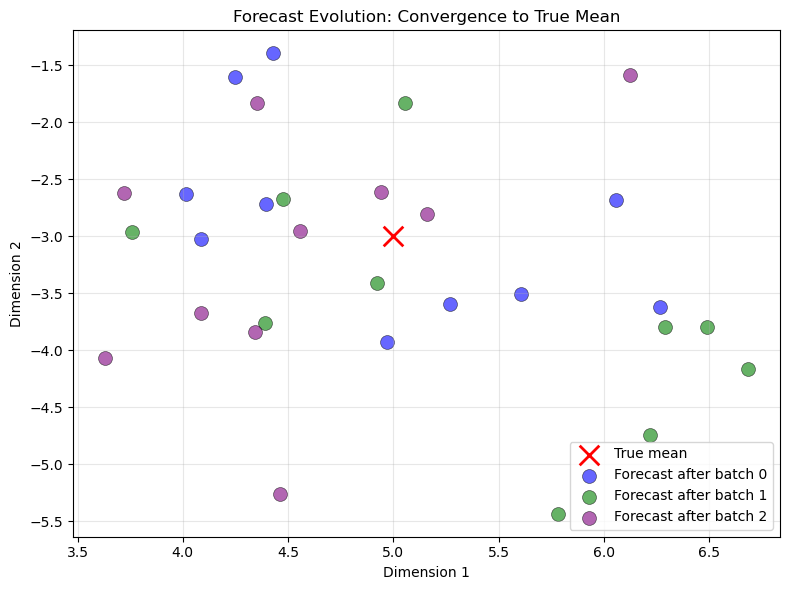

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))

# True data-generating mean
ax.scatter(5.0, -3.0, c='red', s=200, marker='x', 
           label='True mean', zorder=5, edgecolors='black', linewidths=2)

# Plot forecasts from each iteration
colors = ['blue', 'green', 'purple']
for i, forecast in enumerate(forecasts):
    ax.scatter(forecast[:, 0], forecast[:, 1], 
               c=colors[i], alpha=0.6, s=100, 
               label=f'Forecast after batch {i}', 
               edgecolors='black', linewidths=0.5)

ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.set_title('Forecast Evolution: Convergence to True Mean')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:

print("=== Forecast Summaries ===")
for i, forecast in enumerate(forecasts):
    forecast_dist = EmpiricalDistribution(forecast)
    print(f"Forecast {i}: {forecast_dist}")
print(f"\nTrue data-generating mean: [5.0, -3.0]")
print("\nNotice how the forecast means converge toward [5.0, -3.0] and")
print("the standard deviations decrease as we incorporate more data.")

=== Forecast Summaries ===
Forecast 0: EmpiricalDistribution(n=10, dim=2, uniform, mean=[4.934, -2.87], std=[0.7863, 0.8074])
Forecast 1: EmpiricalDistribution(n=10, dim=2, uniform, mean=[5.407, -3.658], std=[0.9669, 0.9756])
Forecast 2: EmpiricalDistribution(n=10, dim=2, uniform, mean=[4.537, -3.124], std=[0.695, 1.049])

True data-generating mean: [5.0, -3.0]

Notice how the forecast means converge toward [5.0, -3.0] and
the standard deviations decrease as we incorporate more data.
